Results Comparison


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
})

MODEL_COLORS = {
    'Baseline-LR (k=3)': '#78909C',   # blue-grey (baseline)
    'ProtBERT':           '#42A5F5',   # blue
    'ESM-2':              '#66BB6A',   # green
    'ProtT5':             '#FFA726',   # orange
}
DATASET_HATCHES = {'dbAMP': '', 'DRAMP': '///'}
LABEL_COLORS = {
    'AUC_antimicrobial': '#2196F3',
    'AUC_antiviral':     '#4CAF50',
    'AUC_antifungal':    '#FF9800',
    'AUC_anticancer':    '#E91E63',
}
LABEL_NAMES = {
    'AUC_antimicrobial': 'Antimicrobial',
    'AUC_antiviral':     'Antiviral',
    'AUC_antifungal':    'Antifungal',
    'AUC_anticancer':    'Anticancer',
}
MODELS  = ['Baseline-LR (k=3)', 'ProtBERT', 'ESM-2', 'ProtT5']
DATASETS = ['dbAMP', 'DRAMP']
OVERALL_METRICS = ['Subset_Accuracy', 'Macro_Precision', 'Macro_Recall', 'Macro_F1', 'Macro_AUC']
AUC_COLS = ['AUC_antimicrobial', 'AUC_antiviral', 'AUC_antifungal', 'AUC_anticancer']

In [ ]:
df = pd.read_csv('all_results.csv')

dbamp = df[df['Dataset'] == 'dbAMP'].set_index('Model').reindex(MODELS)
dramp = df[df['Dataset'] == 'DRAMP'].set_index('Model').reindex(MODELS)

print('Loaded results:')
print(df.to_string(index=False))

Loaded results:
            Model Dataset  Subset_Accuracy  Macro_Precision  Macro_Recall  Macro_F1  Macro_AUC  AUC_antimicrobial  AUC_antiviral  AUC_antifungal  AUC_anticancer
Baseline-LR (k=3)   dbAMP         0.629026         0.435508      0.480555  0.455194   0.740018           0.858655       0.806124        0.656640        0.638651
Baseline-LR (k=3)   DRAMP         0.608268         0.500600      0.612021  0.541715   0.725396                NaN       0.633333        0.666709        0.876146
         ProtBERT   dbAMP         0.679860         0.510075      0.557205  0.524052   0.780654           0.859357       0.879591        0.771543        0.612126
         ProtBERT   DRAMP         0.547244         0.530012      0.537690  0.491543   0.794703                NaN       0.719161        0.775126        0.889821
            ESM-2   dbAMP         0.634847         0.473257      0.603661  0.520334   0.856450           0.899569       0.881140        0.783061        0.862029
            ESM-2 

In [ ]:
def styled_table(data, title):
    """Return a nicely formatted DataFrame with bold best values per column."""
    display_cols = OVERALL_METRICS + AUC_COLS
    tbl = data[display_cols].copy()
    tbl.columns = [
        'Subset Acc.', 'Macro Prec.', 'Macro Rec.', 'Macro F1', 'Macro AUC',
        'AUC antim.', 'AUC antivir.', 'AUC antifung.', 'AUC anticancer'
    ]
    print(f'\n{'─'*70}')
    print(f'  {title}')
    print(f'{'─'*70}')
    # Mark best (ignoring NaN)
    formatted = tbl.applymap(lambda x: f'{x:.4f}' if pd.notna(x) else 'NaN*')
    for col in tbl.columns:
        valid = tbl[col].dropna()
        if not valid.empty:
            best_idx = valid.idxmax()
            formatted.loc[best_idx, col] = f'**{tbl.loc[best_idx, col]:.4f}**'
    print(formatted.to_string())
    print('\n  ** = best in column')
    if title.startswith('DRAMP'):
        print('  NaN* = undefined (all DRAMP test samples are antimicrobial-positive)')

styled_table(dbamp, 'dbAMP — Test Results')
styled_table(dramp, 'DRAMP — Test Results')


──────────────────────────────────────────────────────────────────────
  dbAMP — Test Results
──────────────────────────────────────────────────────────────────────
                  Subset Acc. Macro Prec.  Macro Rec.    Macro F1   Macro AUC  AUC antim. AUC antivir. AUC antifung. AUC anticancer
Model                                                                                                                              
Baseline-LR (k=3)      0.6290      0.4355      0.4806      0.4552      0.7400      0.8587       0.8061        0.6566         0.6387
ProtBERT           **0.6799**  **0.5101**      0.5572  **0.5241**      0.7807      0.8594       0.8796        0.7715         0.6121
ESM-2                  0.6348      0.4733  **0.6037**      0.5203  **0.8564**  **0.8996**   **0.8811**    **0.7831**     **0.8620**
ProtT5                 0.4757      0.4839      0.5233      0.4461      0.6882      0.6121       0.8270        0.6963         0.6174

  ** = best in column

──────────────────

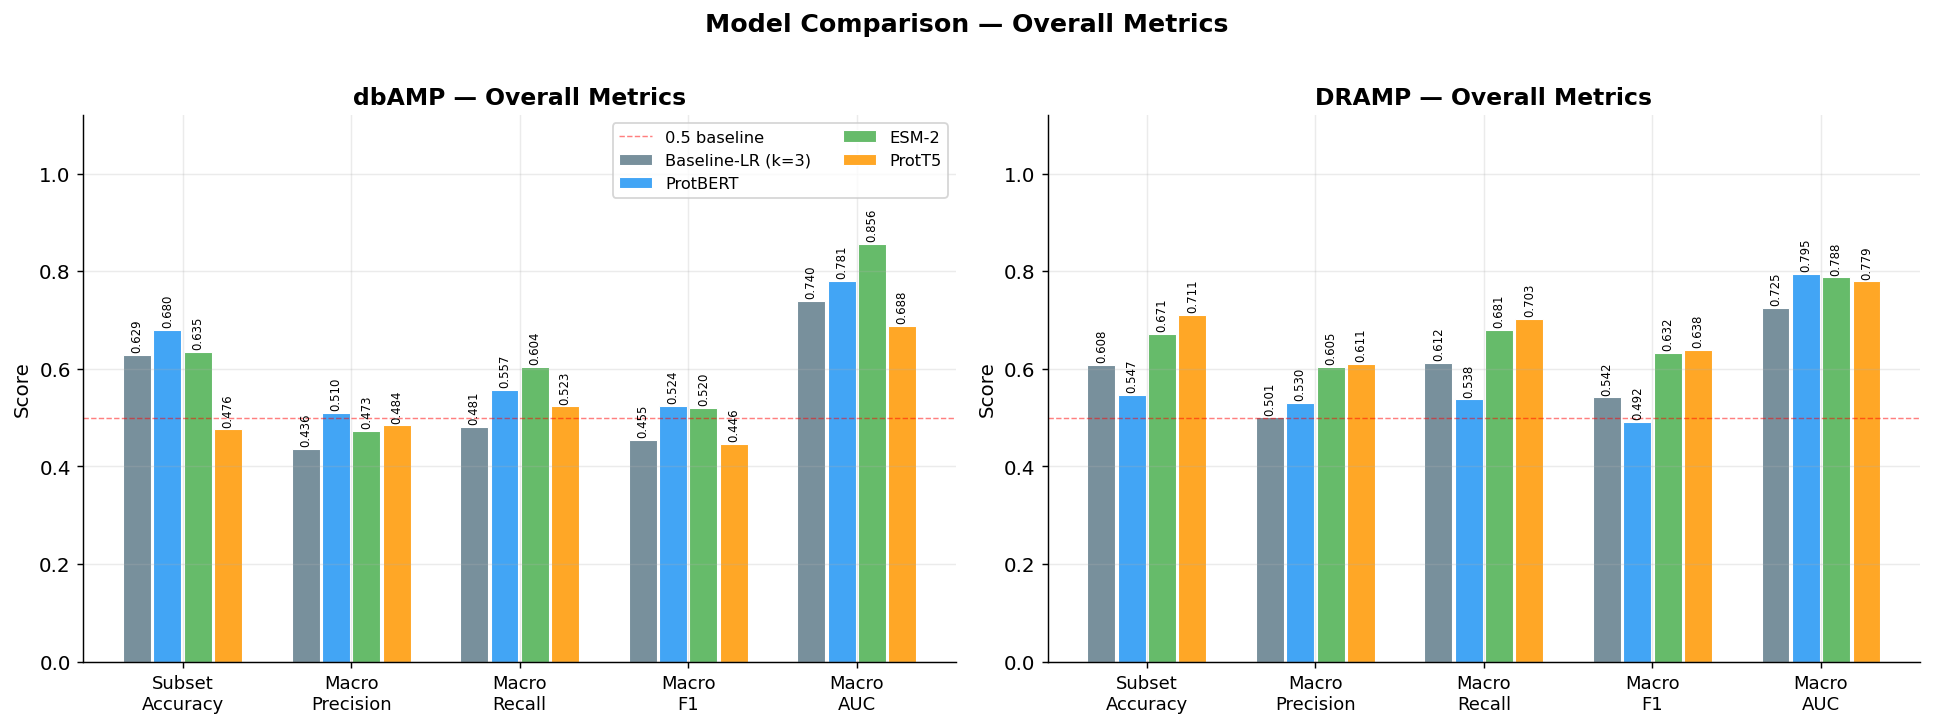

In [ ]:
metric_labels = ['Subset\nAccuracy', 'Macro\nPrecision', 'Macro\nRecall', 'Macro\nF1', 'Macro\nAUC']

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=False)

for ax, (src_name, src_df) in zip(axes, [('dbAMP', dbamp), ('DRAMP', dramp)]):
    x = np.arange(len(OVERALL_METRICS))
    n = len(MODELS)
    total_w = 0.72
    w = total_w / n

    for i, model in enumerate(MODELS):
        vals = src_df.loc[model, OVERALL_METRICS].values.astype(float)
        offset = (i - (n-1)/2) * w
        bars = ax.bar(x + offset, vals, w * 0.92,
                      color=MODEL_COLORS[model], label=model,
                      edgecolor='white', linewidth=0.6)
        # Value labels on top
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                    f'{v:.3f}', ha='center', va='bottom',
                    fontsize=6.5, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=10)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score')
    ax.set_title(f'{src_name} — Overall Metrics', fontsize=13, fontweight='bold')
    ax.axhline(0.5, color='red', linewidth=0.8, linestyle='--', alpha=0.5, label='0.5 baseline')
    if src_name == 'dbAMP':
        ax.legend(loc='upper right', fontsize=9, ncol=2)

plt.suptitle('Model Comparison — Overall Metrics', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

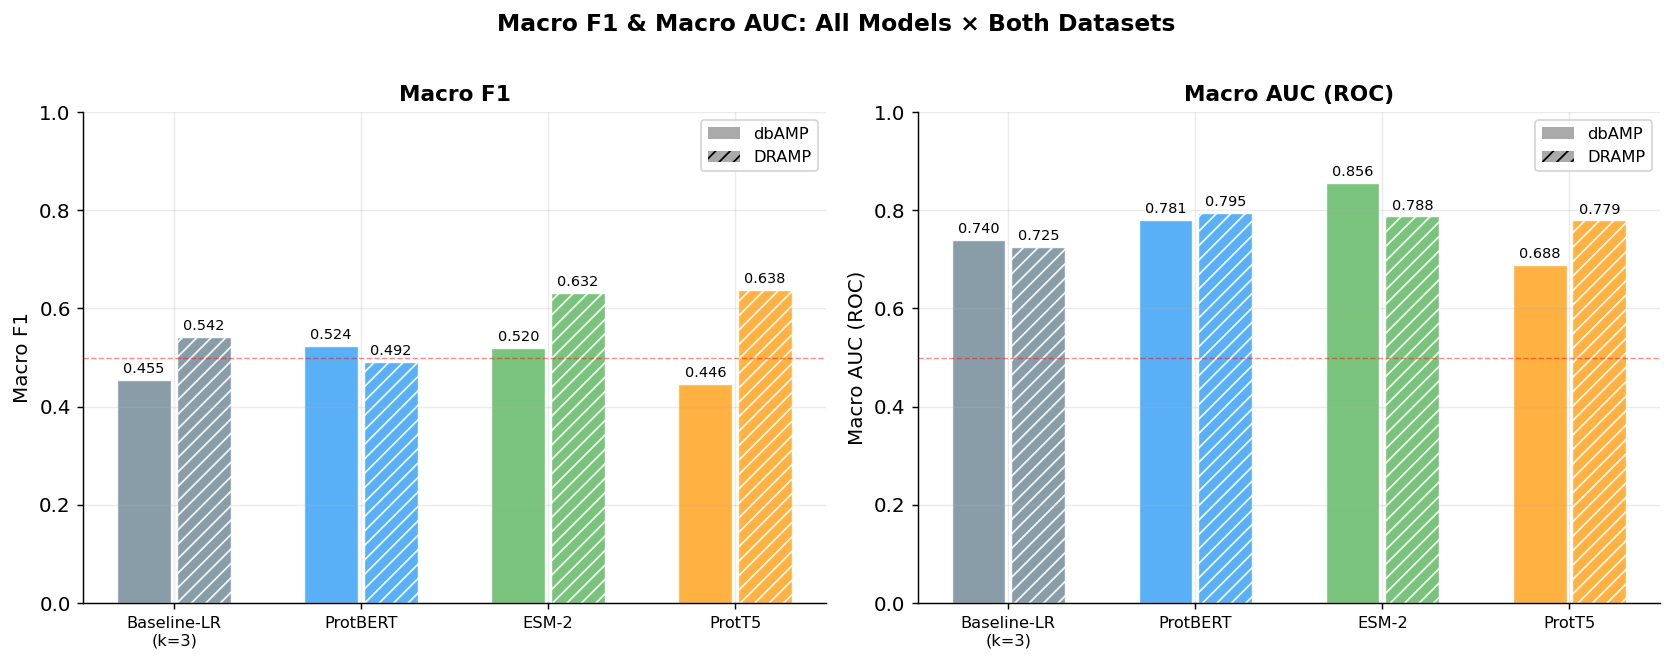

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, ylabel in zip(axes,
                               ['Macro_F1', 'Macro_AUC'],
                               ['Macro F1', 'Macro AUC (ROC)']):
    x = np.arange(len(MODELS))
    w = 0.32
    for j, (ds, hatch) in enumerate(zip(DATASETS, ['', '///'])):
        src_df = dbamp if ds == 'dbAMP' else dramp
        vals = src_df[metric].values.astype(float)
        bars = ax.bar(x + (j - 0.5) * w, vals, w * 0.9,
                      color=[MODEL_COLORS[m] for m in MODELS],
                      hatch=hatch, edgecolor='white', linewidth=0.8,
                      label=ds, alpha=0.88)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.008,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ', '\n') for m in MODELS], fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontsize=12, fontweight='bold')
    ax.axhline(0.5, color='red', linewidth=0.8, linestyle='--', alpha=0.45)
    # Dataset legend (hatch)
    handles = [
        mpatches.Patch(facecolor='#aaa', label='dbAMP'),
        mpatches.Patch(facecolor='#aaa', hatch='///', label='DRAMP'),
    ]
    ax.legend(handles=handles, fontsize=9)

plt.suptitle('Macro F1 & Macro AUC: All Models × Both Datasets', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

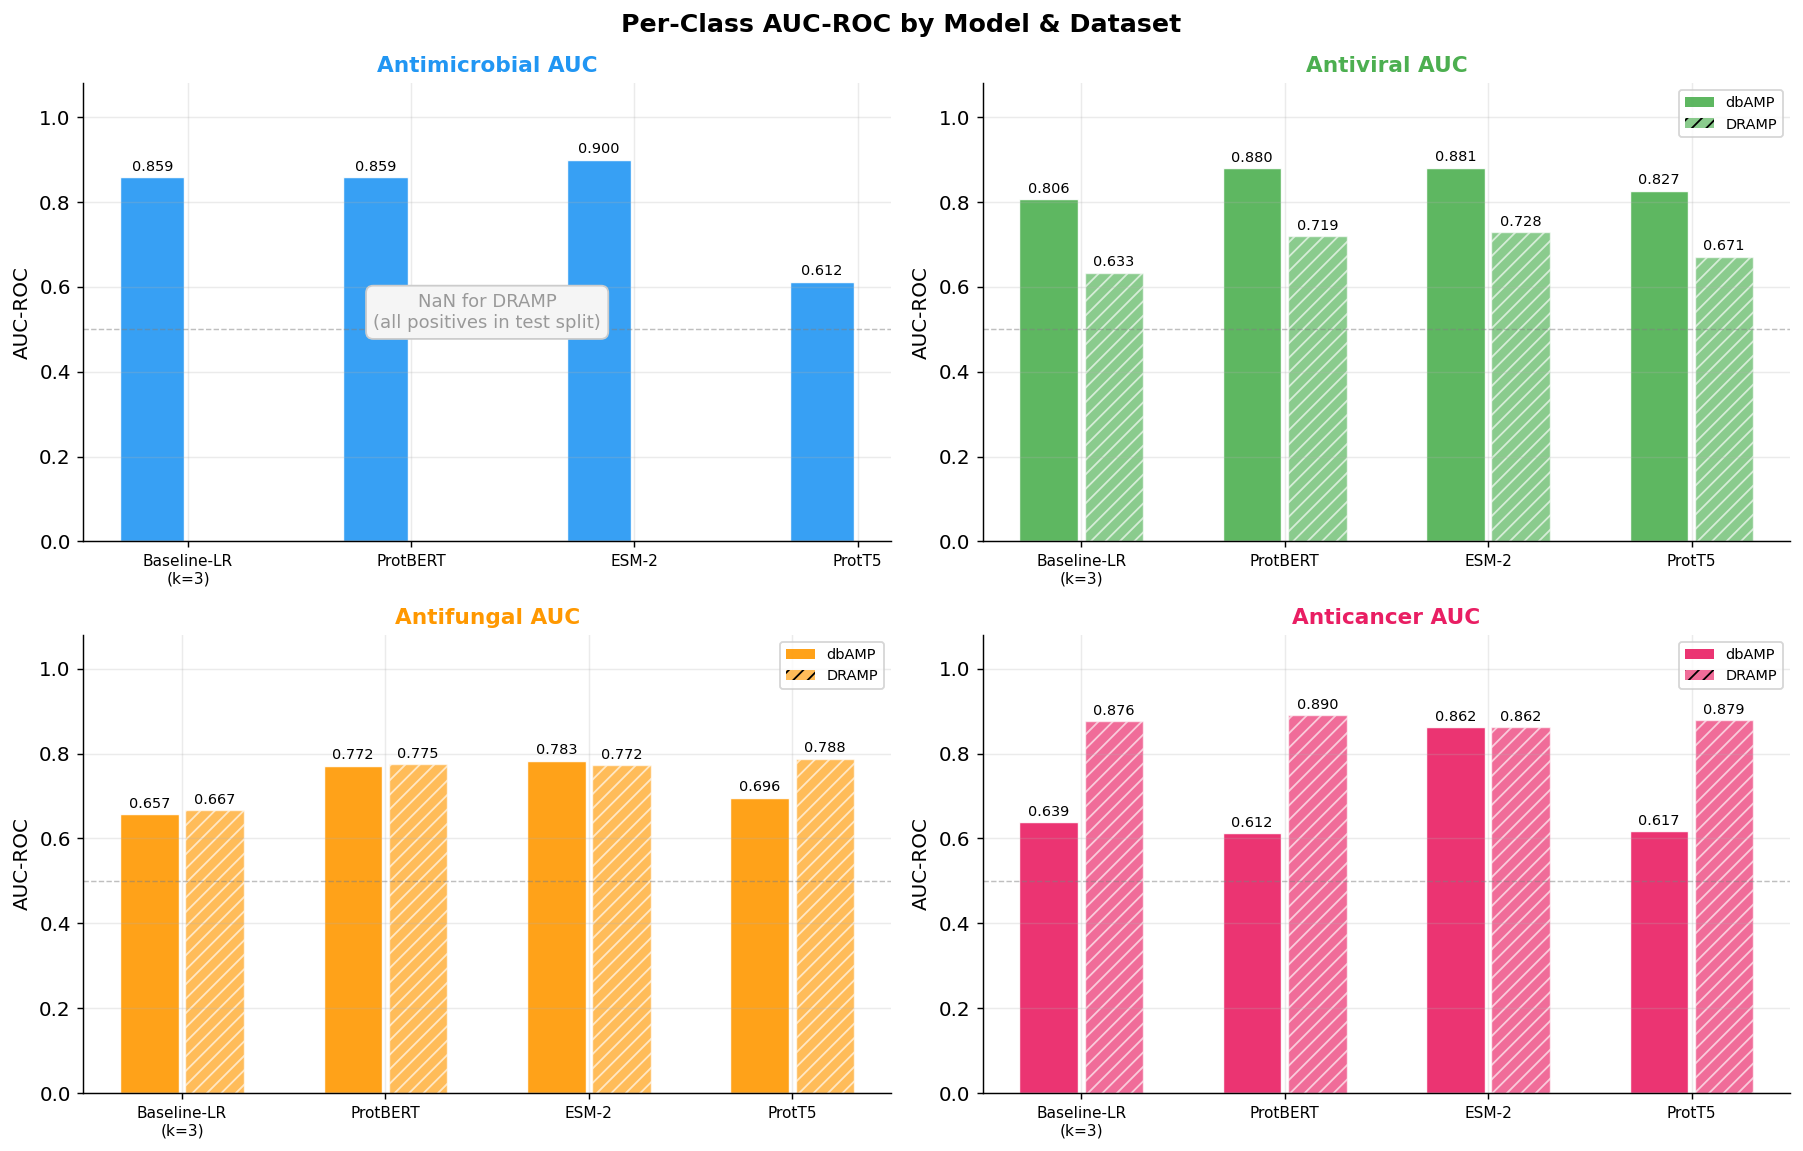

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, AUC_COLS):
    label_name = LABEL_NAMES[col]
    color = LABEL_COLORS[col]

    x = np.arange(len(MODELS))
    w = 0.32

    for j, ds in enumerate(DATASETS):
        src_df = dbamp if ds == 'dbAMP' else dramp
        vals = src_df[col].values.astype(float)

        # DRAMP antimicrobial is NaN — skip bars, add annotation
        if ds == 'DRAMP' and col == 'AUC_antimicrobial':
            ax.text(0.5, 0.5, 'NaN for DRAMP\n(all positives in test split)',
                    transform=ax.transAxes, ha='center', va='center',
                    fontsize=10, color='#999',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5f5f5', edgecolor='#ccc'))
            continue

        alpha = 0.9 if ds == 'dbAMP' else 0.65
        hatch = '' if ds == 'dbAMP' else '///'
        bars = ax.bar(x + (j - 0.5) * w, vals, w * 0.9,
                      color=color, hatch=hatch, edgecolor='white',
                      linewidth=0.8, alpha=alpha, label=ds)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2, v + 0.008,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ', '\n') for m in MODELS], fontsize=8.5)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel('AUC-ROC')
    ax.set_title(f'{label_name} AUC', fontsize=12, fontweight='bold', color=color)
    ax.axhline(0.5, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
    if col != 'AUC_antimicrobial':
        handles = [
            mpatches.Patch(facecolor=color, alpha=0.9, label='dbAMP'),
            mpatches.Patch(facecolor=color, alpha=0.65, hatch='///', label='DRAMP'),
        ]
        ax.legend(handles=handles, fontsize=8)

plt.suptitle('Per-Class AUC-ROC by Model & Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

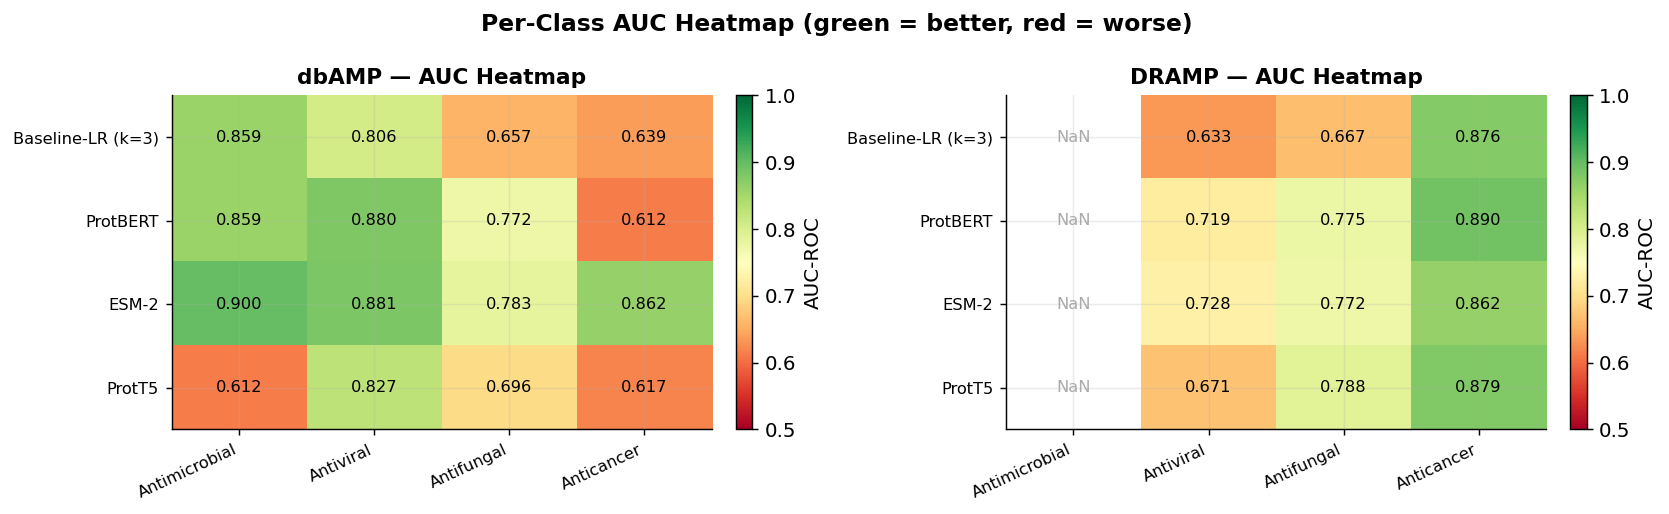

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (ds, src_df) in zip(axes, [('dbAMP', dbamp), ('DRAMP', dramp)]):
    mat = src_df[AUC_COLS].values.astype(float)  # (4 models, 4 classes)
    im = ax.imshow(mat, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')

    ax.set_xticks(range(4))
    ax.set_xticklabels([LABEL_NAMES[c] for c in AUC_COLS], rotation=25, ha='right', fontsize=9)
    ax.set_yticks(range(4))
    ax.set_yticklabels(MODELS, fontsize=9)
    ax.set_title(f'{ds} — AUC Heatmap', fontsize=12, fontweight='bold')

    for i in range(4):
        for j in range(4):
            v = mat[i, j]
            txt = f'{v:.3f}' if not np.isnan(v) else 'NaN'
            ax.text(j, i, txt, ha='center', va='center', fontsize=9,
                    color='black' if not np.isnan(v) else '#aaa')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='AUC-ROC')

plt.suptitle('Per-Class AUC Heatmap (green = better, red = worse)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
rank_metrics = OVERALL_METRICS + [c for c in AUC_COLS if c != 'AUC_antimicrobial']

print('Model Rankings (1 = best) — higher metric = better rank')
print('\n── dbAMP ──')
ranks_db = dbamp[rank_metrics].rank(ascending=False).astype(int)
print(ranks_db.to_string())

print('\n── DRAMP (AUC_antimicrobial excluded due to NaN) ──')
ranks_dr = dramp[rank_metrics].rank(ascending=False).astype(int)
print(ranks_dr.to_string())

print('\n── Mean rank across all metrics ──')
mean_ranks = pd.DataFrame({
    'dbAMP mean rank':  ranks_db.mean(axis=1).round(2),
    'DRAMP mean rank':  ranks_dr.mean(axis=1).round(2),
    'Overall mean rank': pd.concat([ranks_db, ranks_dr]).groupby(level=0).mean().mean(axis=1).round(2),
})
print(mean_ranks.sort_values('Overall mean rank').to_string())

Model Rankings (1 = best) — higher metric = better rank

── dbAMP ──
                   Subset_Accuracy  Macro_Precision  Macro_Recall  Macro_F1  Macro_AUC  AUC_antiviral  AUC_antifungal  AUC_anticancer
Model                                                                                                                                
Baseline-LR (k=3)                3                4             4         3          3              4               4               2
ProtBERT                         1                1             2         1          2              2               2               4
ESM-2                            2                3             1         2          1              1               1               1
ProtT5                           4                2             3         4          4              3               3               3

── DRAMP (AUC_antimicrobial excluded due to NaN) ──
                   Subset_Accuracy  Macro_Precision  Macro_Recall  Macro_F

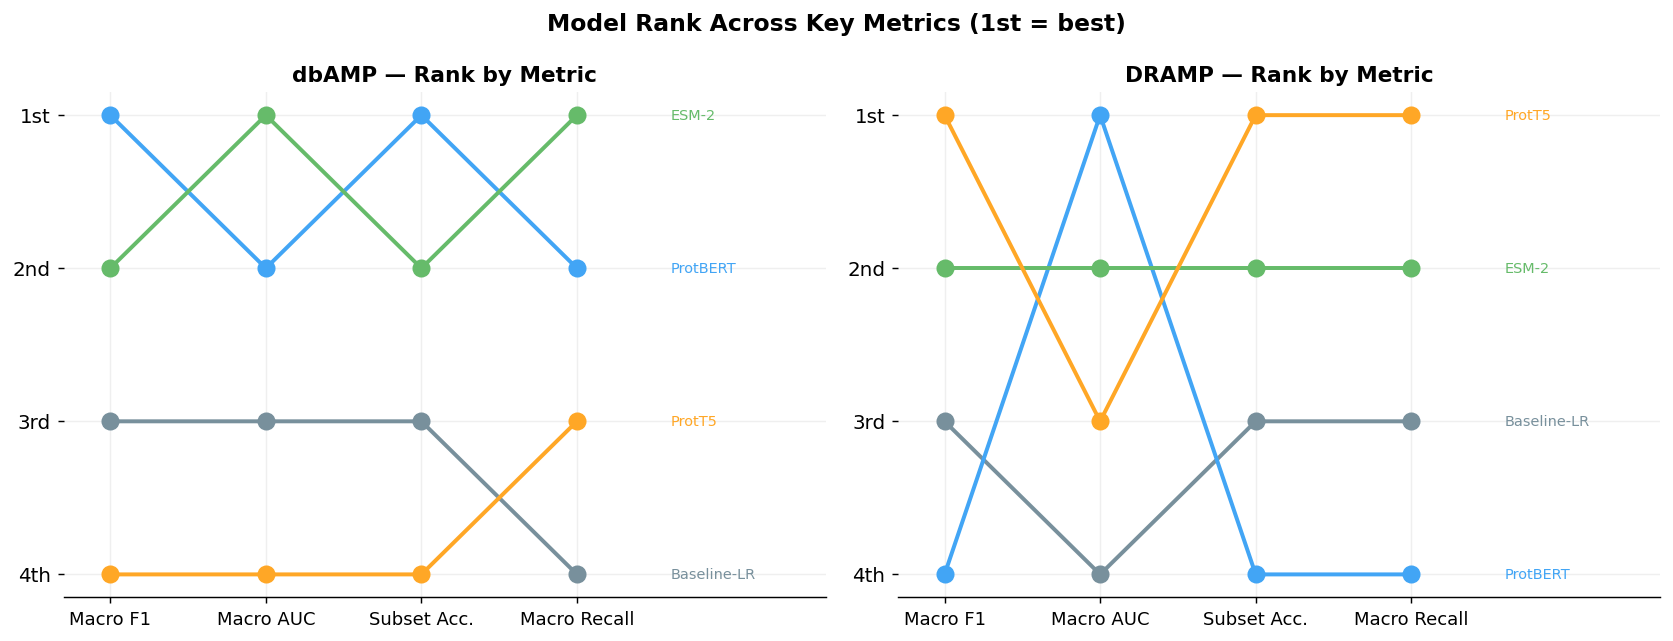

In [ ]:
key_metrics = ['Macro_F1', 'Macro_AUC', 'Subset_Accuracy', 'Macro_Recall']
metric_short = ['Macro F1', 'Macro AUC', 'Subset Acc.', 'Macro Recall']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (ds, src_df) in zip(axes, [('dbAMP', dbamp), ('DRAMP', dramp)]):
    ranks = src_df[key_metrics].rank(ascending=False).astype(int)
    x = np.arange(len(key_metrics))

    for model in MODELS:
        y = ranks.loc[model].values
        ax.plot(x, y, 'o-', color=MODEL_COLORS[model], linewidth=2.2,
                markersize=9, label=model, zorder=3)
        # Label at end
        ax.text(len(key_metrics) - 0.5 + 0.1, y[-1], model.split()[0],
                va='center', fontsize=8, color=MODEL_COLORS[model])

    ax.set_xticks(x)
    ax.set_xticklabels(metric_short, fontsize=10)
    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels(['1st', '2nd', '3rd', '4th'])
    ax.invert_yaxis()
    ax.set_title(f'{ds} — Rank by Metric', fontsize=12, fontweight='bold')
    ax.set_xlim(-0.3, len(key_metrics) - 0.5 + 1.1)
    ax.grid(True, alpha=0.2)
    ax.spines['left'].set_visible(False)

plt.suptitle('Model Rank Across Key Metrics (1st = best)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

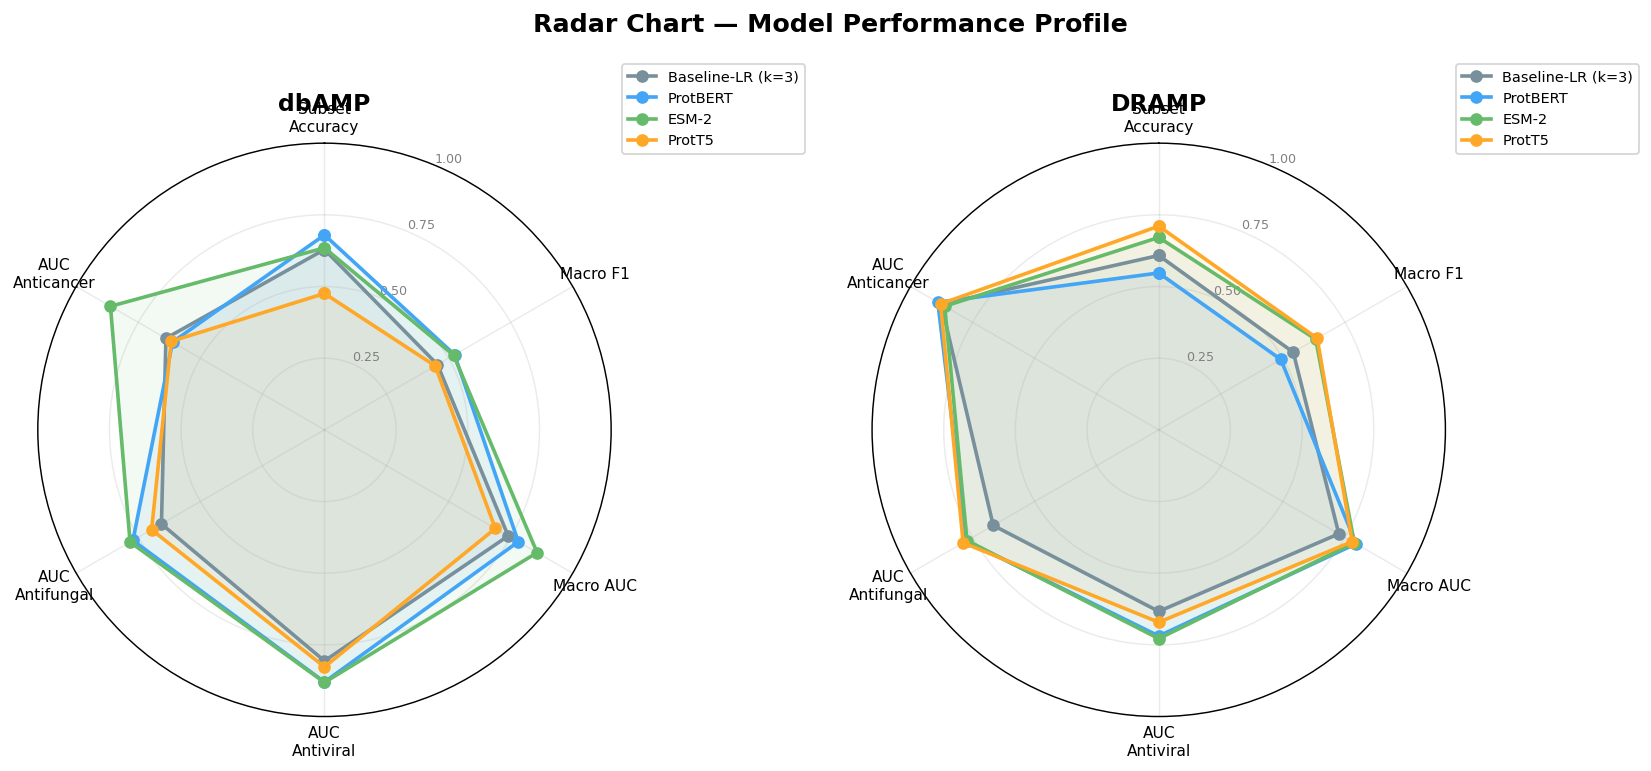

In [ ]:

RADAR_METRICS = ['Subset_Accuracy', 'Macro_F1', 'Macro_AUC',
                 'AUC_antiviral', 'AUC_antifungal', 'AUC_anticancer']
RADAR_LABELS  = ['Subset\nAccuracy', 'Macro F1', 'Macro AUC',
                 'AUC\nAntiviral', 'AUC\nAntifungal', 'AUC\nAnticancer']

N = len(RADAR_METRICS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(1, 2, figsize=(13, 6),
                          subplot_kw=dict(polar=True))

for ax, (ds, src_df) in zip(axes, [('dbAMP', dbamp), ('DRAMP', dramp)]):
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), RADAR_LABELS, fontsize=8.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=7, color='grey')

    for model in MODELS:
        vals = src_df.loc[model, RADAR_METRICS].values.astype(float)
        vals = np.nan_to_num(vals, nan=0.0)
        vals_plot = vals.tolist() + vals[:1].tolist()
        ax.plot(angles, vals_plot, 'o-', linewidth=2, color=MODEL_COLORS[model],
                label=model)
        ax.fill(angles, vals_plot, alpha=0.08, color=MODEL_COLORS[model])

    ax.set_title(f'{ds}', fontsize=13, fontweight='bold', pad=18)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)

plt.suptitle('Radar Chart — Model Performance Profile', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print('=' * 65)
print('  KEY TAKEAWAYS — Multilabel Peptide Classification')
print('=' * 65)

for ds, src_df in [('dbAMP', dbamp), ('DRAMP', dramp)]:
    print(f'\n{'─'*55}')
    print(f'  {ds}')
    print(f'{'─'*55}')
    best_f1   = src_df['Macro_F1'].idxmax()
    best_auc  = src_df['Macro_AUC'].idxmax()
    best_acc  = src_df['Subset_Accuracy'].idxmax()
    worst_f1  = src_df['Macro_F1'].idxmin()
    print(f'  Best Macro F1  : {best_f1:25s}  ({src_df.loc[best_f1, "Macro_F1"]:.4f})')
    print(f'  Best Macro AUC : {best_auc:25s}  ({src_df.loc[best_auc, "Macro_AUC"]:.4f})')
    print(f'  Best Subset Acc: {best_acc:25s}  ({src_df.loc[best_acc, "Subset_Accuracy"]:.4f})')
    print(f'  Worst Macro F1 : {worst_f1:25s}  ({src_df.loc[worst_f1, "Macro_F1"]:.4f})')

    # Per-class AUC best
    print('  Per-class AUC winners:')
    for col in AUC_COLS:
        valid = src_df[col].dropna()
        if valid.empty:
            print(f'    {LABEL_NAMES[col]:15s}: NaN (excluded)')
        else:
            winner = valid.idxmax()
            print(f'    {LABEL_NAMES[col]:15s}: {winner:25s} ({valid.max():.4f})')


  KEY TAKEAWAYS — Multilabel Peptide Classification

───────────────────────────────────────────────────────
  dbAMP
───────────────────────────────────────────────────────
  Best Macro F1  : ProtBERT                   (0.5241)
  Best Macro AUC : ESM-2                      (0.8564)
  Best Subset Acc: ProtBERT                   (0.6799)
  Worst Macro F1 : ProtT5                     (0.4461)
  Per-class AUC winners:
    Antimicrobial  : ESM-2                     (0.8996)
    Antiviral      : ESM-2                     (0.8811)
    Antifungal     : ESM-2                     (0.7831)
    Anticancer     : ESM-2                     (0.8620)

───────────────────────────────────────────────────────
  DRAMP
───────────────────────────────────────────────────────
  Best Macro F1  : ProtT5                     (0.6382)
  Best Macro AUC : ProtBERT                   (0.7947)
  Best Subset Acc: ProtT5                     (0.7106)
  Worst Macro F1 : ProtBERT                   (0.4915)
  Per-class AUC w